In [1]:
import argparse
import os
import time
import logging
from math import sqrt

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import optuna
import optuna.integration.lightgbm as lgb
from filelock import FileLock
from scipy.linalg import solve_discrete_lyapunov
from sklearn.mixture import GaussianMixture
from sklearn.model_selection import train_test_split
from lightgbm import early_stopping


optuna.logging.set_verbosity(optuna.logging.WARNING)
optuna.logging.set_verbosity(optuna.logging.WARN)
logging.basicConfig(level=logging.WARNING)

# Kernelized Stein Discrepancy

In [2]:
def u_q(x_1, x_2, mu, var, pi, h):
    # Compute log probabilities and weights for GMM components
    log_probs = torch.log(pi) - 0.5 * torch.log(var) - (x_1 - mu) ** 2 / 2 / var
    log_weights1 = torch.log(x_1) - torch.log(var)
    log_weights2 = torch.log(mu) - torch.log(var)
    log_sum_weights1 = torch.logsumexp(log_probs + log_weights1, dim=1, keepdim=True)
    log_sum_weights2 = torch.logsumexp(log_probs + log_weights2, dim=1, keepdim=True)
    log_sum_probs = torch.logsumexp(log_probs, dim=1, keepdim=True)
    sq1 = torch.exp(log_sum_weights1 - log_sum_probs) - torch.exp(log_sum_weights2 - log_sum_probs)

    # Compute log probabilities and weights for the second input
    log_probs = (torch.log(pi) - 0.5 * torch.log(var)).unsqueeze(1) - (x_2 - mu.unsqueeze(1)) ** 2 / 2 / var.unsqueeze(1)
    log_weights1 = torch.log(x_2) - torch.log(var).unsqueeze(1)
    log_weights2 = (torch.log(mu) - torch.log(var)).unsqueeze(1)
    log_sum_weights1 = torch.logsumexp(log_probs + log_weights1, dim=0, keepdim=True)
    log_sum_weights2 = torch.logsumexp(log_probs + log_weights2, dim=0, keepdim=True)
    log_sum_probs = torch.logsumexp(log_probs, dim=0, keepdim=True)
    sq2 = torch.exp(log_sum_weights1 - log_sum_probs) - torch.exp(log_sum_weights2 - log_sum_probs)

    # Compute the final result based on bandwidth h
    if h == float('inf'):
        return sq1 * sq2
    else:
        return torch.exp(-(x_1 - x_2) ** 2 / 2 / (h ** 2)) * (
                    sq1 * sq2 - (sq1 - sq2) * (x_1 - x_2) / h ** 2 + 1 / h ** 2 - (x_1 - x_2) ** 2 / h ** 4)

# Data Generation

In [3]:
def gen_data(n_train, n_test, n_dist, train_interval, test_interval):
    matrix = np.load('matrix.npz')
    A_chaotic_adjusted = matrix['A_chaotic_adjusted']
    Sigma = matrix['Sigma']
    test_Sigma = matrix['test_Sigma']
    P = len(A_chaotic_adjusted)
    Sigma_stationary = solve_discrete_lyapunov(A_chaotic_adjusted, Sigma)
    test_Sigma_stationary = solve_discrete_lyapunov(A_chaotic_adjusted, test_Sigma)

    # Generate training data
    rng = np.random.default_rng()
    X_chain = np.zeros(((n_train - 1) * train_interval + 2, P))
    X_t = rng.multivariate_normal(np.zeros(P), Sigma_stationary)
    for t in range((n_train - 1) * train_interval + 2):
        X_t = A_chaotic_adjusted @ X_t + rng.multivariate_normal(np.zeros(P), Sigma)
        X_chain[t, :] = X_t
    X_train = X_chain[:-1:train_interval]
    y_train = np.sqrt(np.sum(X_chain[1::train_interval] ** 2, axis=1)) / 100

    # Split the training data into training and validation
    X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2)

    # Generate test data
    X_chain = np.zeros(((n_test - 1) * test_interval + 2, P))
    X_t = rng.multivariate_normal(np.zeros(P), test_Sigma_stationary)
    for t in range((n_test - 1) * test_interval + 2):
        X_t = A_chaotic_adjusted @ X_t + rng.multivariate_normal(np.zeros(P), test_Sigma)
        X_chain[t, :] = X_t
    X_test = X_chain[:-1:test_interval]
    y_test = np.sqrt(np.sum(X_chain[1::test_interval] ** 2, axis=1)) / 100

    # Generate dist data
    X_dist = rng.multivariate_normal(np.zeros(P), test_Sigma_stationary, size=n_dist)
    X_step_dist = X_dist @ A_chaotic_adjusted.T + rng.multivariate_normal(np.zeros(P), test_Sigma, size=n_dist)
    y_dist = np.sqrt(np.sum(X_step_dist ** 2, axis=1)) / 100

    # Fit a lightgbm model
    train_data = lgb.Dataset(X_train, label=y_train)
    val_data = lgb.Dataset(X_val, label=y_val, reference=train_data)

    params = {
        "objective": "regression",
        "metric": "mse",
        "verbosity": -1,
        "boosting_type": "gbdt",
    }

    model = lgb.train(
        params,
        train_data,
        valid_sets=[train_data, val_data],
        callbacks=[early_stopping(100, verbose=False)],
    )

    y_test_hat = model.predict(X_test, num_iteration=model.best_iteration)

    return X_train, y_train, X_val, y_val, X_test, y_test, y_test_hat, y_dist

# Main Algorithm

In [4]:
def calibration(y_test, y_test_hat, y_dist, n_components, is_standardize=True, lamb=0.01,
                max_step=201, tolerance=20, bandwidth=3, draw_plot=False):

    # Fit Gaussian Mixture Model (GMM) to the training data
    gmm = GaussianMixture(n_components=n_components)
    gmm.fit(y_dist.reshape(-1, 1))

    # Extract GMM parameters
    means = torch.tensor(gmm.means_.flatten(), dtype=torch.float64, device=device)
    weights = torch.tensor(gmm.weights_.flatten(), dtype=torch.float64, device=device)
    covariances = torch.tensor(gmm.covariances_.flatten(), dtype=torch.float64, device=device)
    overall_mean = torch.dot(weights, means)
    overall_std = torch.sqrt(torch.dot(weights, means ** 2 + covariances) - overall_mean ** 2)


    # Normalize the test predictions
    y_test_hat_tensor = torch.tensor(y_test_hat, dtype=torch.float64, device=device)
    if is_standardize:
        y_test_hat_tensor = torch.clip((y_test_hat_tensor - torch.mean(y_test_hat_tensor)) / torch.std(
            y_test_hat_tensor) * overall_std + overall_mean, 5, np.inf)
    else:
        y_test_hat_tensor = torch.clip(y_test_hat_tensor, 0, np.inf)
    y_test_hat_tensor = y_test_hat_tensor.clone().detach().requires_grad_(True)
    y_test_hat_tensor_numpy = y_test_hat_tensor.clone().detach().cpu().numpy()

    with torch.no_grad():
        h = bandwidth * torch.std(y_test_hat_tensor).item()

    # Pre-calculate quantiles for dist_WDL
    q_vec = torch.arange(1, 1000, dtype=torch.float64) / 1000
    quantiles = np.percentile(y_dist, q_vec * 100)

    # Early stopping setup
    best_results = {'dist_wdl': np.sum((np.quantile(y_test_hat_tensor_numpy, q_vec) - quantiles) ** 2),
                    'best_test_y_hat': y_test_hat_tensor_numpy}
    # print(best_results['dist_wdl'])
    early_stopping_patience = 0

    n_test = len(y_test_hat_tensor)

    # Perform gradient descent with early stopping based on dist_WDL
    for step in range(max_step):
        pairwise_values = u_q(y_test_hat_tensor.unsqueeze(1), y_test_hat_tensor.unsqueeze(0), means, covariances,
                              weights, h)
        torch.diagonal(pairwise_values)[:] = 0
        test_statistic = torch.sum(pairwise_values) / sqrt(n_test)
        test_statistic.backward()

        # Clip gradients
        gradient = y_test_hat_tensor.grad
        gradient = torch.clip(gradient, -5 * torch.median(torch.abs(gradient)), 5 * torch.median(torch.abs(gradient)))

        with torch.no_grad():
            gradient /= torch.sqrt(torch.mean(gradient ** 2)) / torch.std(y_test_hat_tensor)
            # Adjust predictions to minimize discrepancy
            y_test_hat_tensor -= lamb * gradient

        y_test_hat_tensor.grad.zero_()  # Reset gradients

        # Calculate dist_WDL (Wasserstein distance between y_test_hat and quantiles)
        y_test_hat_numpy = y_test_hat_tensor.detach().cpu().clone().numpy()
        dist_WDL = np.sum((np.quantile(y_test_hat_numpy, q_vec) - quantiles) ** 2)
        # print(dist_WDL)

        # Early stopping logic
        if dist_WDL < best_results['dist_wdl']:  # Update the best results if improvement
            best_results = {
                'dist_wdl': dist_WDL,
                'best_test_y_hat': y_test_hat_numpy
            }
            early_stopping_patience = 0  # Reset patience if there's improvement
        else:
            early_stopping_patience += 1  # Increment patience if no improvement

        # Trigger early stopping if no improvement for 'tol' steps
        if early_stopping_patience >= tolerance:
            # print(f"Early stopping at step {step} for tolerance {tolerance} due to no improvement in dist_WDL.")
            break

    y_test_opt = best_results['best_test_y_hat']
    # Plot the results if requested
    if draw_plot:
        cmap = plt.get_cmap('coolwarm')
        colors = [cmap((3 - i) / 3) for i in range(4)]
        plt.subplots(figsize=(6, 4))

        breaks = torch.arange(5, 306, 15)

        sns.histplot(y_test, bins=breaks, stat="density", color=colors[0], label=r"True Y (Chaotic) at t+1", alpha=0.5)
        sns.histplot(y_test_opt, bins=breaks, stat="density", color=colors[1], alpha=0.5,
                     label=r"Calibrated Y (Chaotic) at t+1")
        sns.histplot(y_test_hat, bins=breaks, stat="density", color=colors[3], alpha=0.5, label=r"Predicted Y (Chaotic) at t+1")

        x = np.linspace(5, 290, 3000)
        log_prob = gmm.score_samples(x.reshape(-1, 1))
        pdf = np.exp(log_prob)
        plt.plot(x, pdf, color='y', label='Knowledge PDF')


        plt.xlim(-10, 320)
        plt.xlabel(r"$Y$", fontsize=18)
        plt.xticks(fontsize=16)
        plt.ylabel('Density', fontsize=18)
        plt.yticks(fontsize=16)
        plt.tight_layout()
        plt.legend(prop={'size': 12.5})
        plt.savefig(f'fig/dynamic_density.pdf', format='pdf')
        plt.show()
        # plt.close('all')

        plt.subplots(figsize=(6, 4))
        plt.scatter(y_test, y_test_opt, alpha=0.5, color=colors[3])
        plt.xlabel('Y', fontsize=18)
        plt.xticks(fontsize=16)
        plt.ylabel('Predicted Y', fontsize=18)
        plt.yticks(fontsize=16)
        plt.title('True Y vs Predicted Y (Chaotic System)', fontsize=18)
        plt.tight_layout()
        plt.savefig(f'fig/dynamic_scatter.pdf', format='pdf')
        plt.show()
        plt.close('all')

    # Calculate squared errors
    raw_MSE = np.mean((y_test_hat - y_test) ** 2)
    opt_MSE = np.mean((y_test_opt - y_test) ** 2)
    stan_MSE = np.mean((y_test_hat_tensor_numpy - y_test) ** 2)

    # Calculate Wasserstein distance
    true_y_quantile = np.quantile(y_test, q_vec)
    y_test_hat_quantile = np.quantile(y_test_hat, q_vec)
    y_test_opt_quantile = np.quantile(y_test_opt, q_vec)
    y_test_stan_quantile = np.quantile(y_test_hat_tensor_numpy, q_vec)

    raw_WDL = np.mean((true_y_quantile - y_test_hat_quantile) ** 2)
    opt_WDL = np.mean((true_y_quantile - y_test_opt_quantile) ** 2)
    stan_WDL = np.mean((true_y_quantile - y_test_stan_quantile) ** 2)


    return raw_MSE, opt_MSE, stan_MSE, raw_WDL, opt_WDL, stan_WDL

In [5]:
if torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

In [6]:
n_train = 1000
n_test = 1000
n_dist = 10000
train_interval = 10
test_interval = 10
n_components = 15
is_standardize = True
lamb = 0.01
max_step = 201
tolerance = 20
bandwidth = 3

# Figure 4

min_child_samples, val_score: 11.767636: 100%|###########################################| 5/5 [00:02<00:00,  2.11it/s]


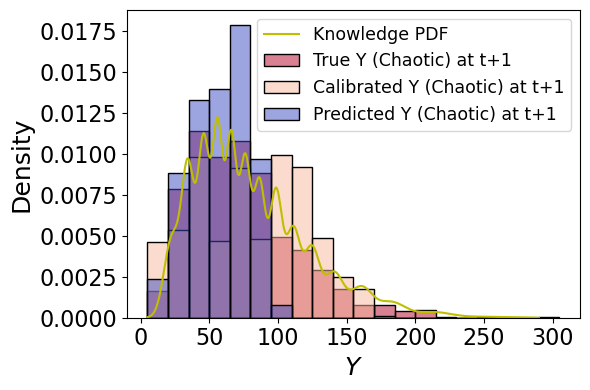

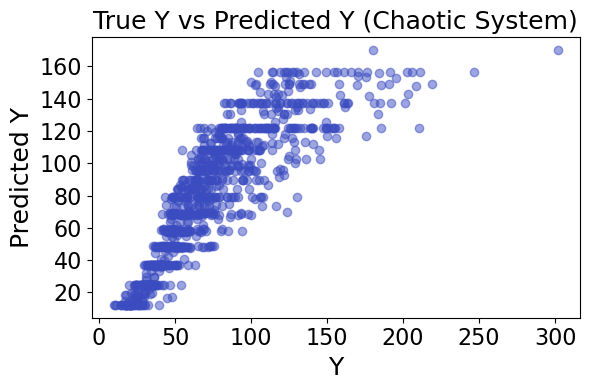

Raw MSE: 847.7445, Opt MSE: 493.8334, Stan MSE: 512.6595
Raw WDL: 665.1855, Opt WDL: 188.9360, Stan WDL: 206.8918


In [7]:
X_train, Y_train, X_val, Y_val, X_test, Y_test, Y_test_pred, \
        Y_dist = gen_data(n_train, n_test, n_dist, train_interval, test_interval)
raw_MSE, opt_MSE, stan_MSE, raw_WDL, opt_WDL, stan_WDL = calibration(Y_test, Y_test_pred, Y_dist, n_components,
                                                                     is_standardize, lamb, max_step, tolerance,
                                                                     bandwidth, draw_plot=True)
print(f"Raw MSE: {raw_MSE:.4f}, Opt MSE: {opt_MSE:.4f}, Stan MSE: {stan_MSE:.4f}")
print(f"Raw WDL: {raw_WDL:.4f}, Opt WDL: {opt_WDL:.4f}, Stan WDL: {stan_WDL:.4f}")